# Approach 3: VAD + Speaker Diarization

This notebook extends the VAD baseline by adding **speaker diarization**.

Pipeline:
1. Use **Silero VAD** to generate candidate conversation windows.
2. Run **pyannote speaker diarization** inside each candidate window.
3. Extract turn-taking features such as number of speakers, number of turns, speaker switches, and dominant-speaker share.
4. Score each candidate for how likely it is to be a real customer-facing interaction.
5. Export the **final predicted two customer conversations** for each audio file.

Important limitation:
> Diarization gives speaker clusters, not identities. It helps detect interaction structure, but it does not directly tell us which speaker is the customer or salesperson.


In [8]:
# Run this once in a fresh environment if needed.
%pip install -q silero-vad torch torchaudio pyannote.audio matplotlib pandas ipython
# If you are using the repo environment instead, run: uv sync


Note: you may need to restart the kernel to use updated packages.


## Setup Note

To use `pyannote/speaker-diarization-community-1`, you need a Hugging Face token and must accept the model terms on Hugging Face first.

Set the token before running the notebook:

```python
import os
os.environ["HF_TOKEN"] = "your_token_here"
```


In [9]:
from __future__ import annotations

import json
import os
import inspect
from importlib.metadata import version as package_version
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd() / ".mpl_cache").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchaudio
import huggingface_hub
from silero_vad import get_speech_timestamps, load_silero_vad

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

def patch_hf_hub_download_auth_arg():
    original = huggingface_hub.hf_hub_download
    if getattr(original, "_patched_use_auth_token", False):
        return

    def wrapped_hf_hub_download(*args, **kwargs):
        if "use_auth_token" in kwargs and "token" not in kwargs:
            kwargs["token"] = kwargs.pop("use_auth_token")
        else:
            kwargs.pop("use_auth_token", None)
        return original(*args, **kwargs)

    wrapped_hf_hub_download._patched_use_auth_token = True
    huggingface_hub.hf_hub_download = wrapped_hf_hub_download


patch_hf_hub_download_auth_arg()

try:
    from pyannote.audio import Pipeline
    PYANNOTE_AVAILABLE = True
    PYANNOTE_IMPORT_ERROR = None
except ModuleNotFoundError as exc:
    Pipeline = None
    PYANNOTE_AVAILABLE = False
    PYANNOTE_IMPORT_ERROR = exc
    print(
        "pyannote.audio is not installed. Run either `uv sync` from the project root or the notebook install cell before running diarization cells."
    )

torch.set_num_threads(1)


In [10]:
from dotenv import load_dotenv
load_dotenv()

def validate_runtime_dependencies():
    """Check active Torch/NumPy compatibility without pinning NumPy major version.

    Some environments use NumPy 1.x and others use NumPy 2.x. Approach 3 should not
    force reinstalling NumPy. It only needs the installed PyTorch build to interoperate
    with the installed NumPy version.
    """
    try:
        _ = torch.tensor([1.0]).cpu().numpy()
    except Exception as exc:
        raise RuntimeError(
            f"PyTorch cannot interoperate with the active NumPy {np.__version__}. "
            "Do not switch NumPy just for this notebook; instead install a PyTorch build compatible with your current NumPy, "
            "or use the same environment that works for the other approaches."
        ) from exc


validate_runtime_dependencies()

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        has_audio = (candidate / "audio").exists()
        has_repo_marker = (candidate / "ground_truth.json").exists() or (candidate / "approaches").exists() or (candidate / "context.md").exists()
        if has_audio and has_repo_marker:
            return candidate
        # If the notebook is launched from inside approaches/, the parent is the project root.
        if candidate.name == "approaches" and (candidate.parent / "audio").exists():
            return candidate.parent
    raise FileNotFoundError(
        "Could not find project root. Expected a folder containing audio/ and ground_truth.json or approaches/. "
        f"Current working directory was: {start}"
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
OUTPUT_DIR = PROJECT_ROOT / "approaches" / "approach_3_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "audio_dir": PROJECT_ROOT / "audio",
    "output_dir": OUTPUT_DIR,
    "target_sr": 16000,
    "threshold": 0.5,
    "min_speech_duration_ms": 250,
    "max_speech_duration_s": float("inf"),
    "min_silence_duration_ms": 400,
    "speech_pad_ms": 200,
    "merge_gap_s": 1.0,
    "min_region_s": 1.5,
    "conversation_gap_s": 5.0,
    "diarization_model": "pyannote/speaker-diarization-3.1",
    "fallback_diarization_model": "pyannote/speaker-diarization-3.1",
    "upgrade_diarization_model": "pyannote/speaker-diarization-community-1",
    "min_turn_s": 0.35,
    "same_speaker_merge_gap_s": 0.6,
    "min_final_conversation_s": 8.0,
    "expected_conversations": 2,
    "plot_width": 18,
    "plot_height": 4,
}

HF_TOKEN = os.getenv("HF_TOKEN")
PYANNOTE_AUDIO_VERSION = package_version("pyannote-audio") if PYANNOTE_AVAILABLE else "not-installed"
audio_files = sorted(CONFIG["audio_dir"].glob("*.mp3"))

print("Project root:", PROJECT_ROOT)
print("Audio dir:", CONFIG["audio_dir"])
print("Audio files:", [path.name for path in audio_files])
print("Outputs:", OUTPUT_DIR)
print("HF token present:", bool(HF_TOKEN))
print("pyannote.audio version:", PYANNOTE_AUDIO_VERSION)
print("Selected diarization model:", CONFIG["diarization_model"])
print("Optional upgrade model:", CONFIG["upgrade_diarization_model"])

import sys
sys.path.append(str(PROJECT_ROOT / "approaches"))
from output_utils import load_ground_truth, export_uniform_outputs, export_combined_outputs

GROUND_TRUTH = load_ground_truth(PROJECT_ROOT)


Project root: /teamspace/studios/this_studio
Audio dir: /teamspace/studios/this_studio/audio
Audio files: ['Sample1KN.mp3', 'Sample2EN.mp3', 'sample3KN.mp3']
Outputs: /teamspace/studios/this_studio/approaches/approach_3_outputs
HF token present: True
pyannote.audio version: 4.0.4
Selected diarization model: pyannote/speaker-diarization-3.1
Optional upgrade model: pyannote/speaker-diarization-community-1


In [11]:
def format_time(seconds: float) -> str:
    minutes = int(seconds // 60)
    secs = seconds % 60
    return f"{minutes:02d}:{secs:06.3f}"


def add_readable_times(rows: list[dict]):
    for row in rows:
        row["start_hms"] = format_time(row["start"])
        row["end_hms"] = format_time(row["end"])
    return rows


def load_audio_mono_resampled(path: str | Path, target_sr: int = 16000):
    waveform, sr = torchaudio.load(str(path))

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        waveform = resampler(waveform)
        sr = target_sr

    return waveform.squeeze(0).contiguous(), sr


VAD_MODEL = load_silero_vad()


def run_silero_vad_on_tensor(waveform: torch.Tensor, sr: int, cfg: dict):
    speech = get_speech_timestamps(
        waveform,
        VAD_MODEL,
        sampling_rate=sr,
        threshold=cfg["threshold"],
        min_speech_duration_ms=cfg["min_speech_duration_ms"],
        max_speech_duration_s=cfg["max_speech_duration_s"],
        min_silence_duration_ms=cfg["min_silence_duration_ms"],
        speech_pad_ms=cfg["speech_pad_ms"],
        return_seconds=False,
    )

    return [
        {
            "segment_id": idx + 1,
            "start": seg["start"] / sr,
            "end": seg["end"] / sr,
            "duration": (seg["end"] - seg["start"]) / sr,
        }
        for idx, seg in enumerate(speech)
    ]


def merge_close_segments(segments: list[dict], merge_gap_s: float, min_region_s: float):
    if not segments:
        return []

    merged = []
    current = {"start": segments[0]["start"], "end": segments[0]["end"]}

    for seg in segments[1:]:
        if seg["start"] - current["end"] <= merge_gap_s:
            current["end"] = max(current["end"], seg["end"])
        else:
            current["duration"] = current["end"] - current["start"]
            if current["duration"] >= min_region_s:
                merged.append(current)
            current = {"start": seg["start"], "end": seg["end"]}

    current["duration"] = current["end"] - current["start"]
    if current["duration"] >= min_region_s:
        merged.append(current)

    return [
        {
            "region_id": idx + 1,
            "start": seg["start"],
            "end": seg["end"],
            "duration": seg["duration"],
        }
        for idx, seg in enumerate(merged)
    ]


def assign_conversation_ids(regions: list[dict], conversation_gap_s: float):
    if not regions:
        return []

    rows = []
    conversation_id = 1
    previous_end = None

    for region in regions:
        if previous_end is not None and region["start"] - previous_end > conversation_gap_s:
            conversation_id += 1

        row = region.copy()
        row["conversation_id"] = conversation_id
        rows.append(row)
        previous_end = region["end"]

    return rows


def collapse_conversation_groups(region_rows: list[dict]):
    if not region_rows:
        return []

    grouped = []
    current_id = region_rows[0]["conversation_id"]
    current_start = region_rows[0]["start"]
    current_end = region_rows[0]["end"]
    region_count = 1

    for row in region_rows[1:]:
        if row["conversation_id"] == current_id:
            current_end = max(current_end, row["end"])
            region_count += 1
        else:
            grouped.append(
                {
                    "conversation_id": current_id,
                    "start": current_start,
                    "end": current_end,
                    "duration": current_end - current_start,
                    "num_regions": region_count,
                }
            )
            current_id = row["conversation_id"]
            current_start = row["start"]
            current_end = row["end"]
            region_count = 1

    grouped.append(
        {
            "conversation_id": current_id,
            "start": current_start,
            "end": current_end,
            "duration": current_end - current_start,
            "num_regions": region_count,
        }
    )

    return grouped


In [12]:
def ensure_pyannote_available():
    if not PYANNOTE_AVAILABLE:
        raise ModuleNotFoundError(
            "pyannote.audio is not installed. Fix it with `uv sync` from the project root or run the install cell: "
            '`%pip install -q silero-vad torch torchaudio pyannote.audio matplotlib pandas ipython`'
        ) from PYANNOTE_IMPORT_ERROR



def pipeline_from_pretrained_compat(model_name: str, hf_token: str):
    """Load pyannote Pipeline across old and new auth argument names."""
    signature = inspect.signature(Pipeline.from_pretrained)
    if "token" in signature.parameters:
        return Pipeline.from_pretrained(model_name, token=hf_token)
    if "use_auth_token" in signature.parameters:
        return Pipeline.from_pretrained(model_name, use_auth_token=hf_token)
    return Pipeline.from_pretrained(model_name)

def load_diarization_pipeline(cfg: dict, hf_token: str | None):
    ensure_pyannote_available()

    if not hf_token:
        raise ValueError("HF_TOKEN is not set. Add your Hugging Face token before running approach 3.")

    model_name = cfg["diarization_model"]

    try:
        pipeline = pipeline_from_pretrained_compat(model_name, hf_token)
        active_model = model_name
    except TypeError as exc:
        fallback_model = cfg.get("fallback_diarization_model")
        incompatible_model = "plda" in str(exc) or "unexpected keyword argument" in str(exc)
        if fallback_model and fallback_model != model_name and incompatible_model:
            print(
                f"Model {model_name} is incompatible with pyannote.audio {PYANNOTE_AUDIO_VERSION}. Falling back to {fallback_model}."
            )
            pipeline = pipeline_from_pretrained_compat(fallback_model, hf_token)
            active_model = fallback_model
        else:
            raise
    except AttributeError as exc:
        none_model_error = "'NoneType' object has no attribute 'eval'" in str(exc)
        if none_model_error:
            raise RuntimeError(
                "pyannote could not load one of the gated pretrained models. This usually means the Hugging Face token is missing access or the model terms were not accepted. "
                f"Accept the model conditions for {model_name} on Hugging Face, verify HF_TOKEN, then restart the kernel and rerun."
            ) from exc
        raise

    if torch.cuda.is_available():
        pipeline.to(torch.device("cuda"))

    return pipeline, active_model


def merge_adjacent_same_speaker_turns(turns: list[dict], gap_s: float):
    if not turns:
        return []

    turns = sorted(turns, key=lambda row: (row["start"], row["end"]))
    merged = [turns[0].copy()]

    for turn in turns[1:]:
        last = merged[-1]
        if turn["speaker_label"] == last["speaker_label"] and turn["start"] - last["end"] <= gap_s:
            last["end"] = max(last["end"], turn["end"])
            last["duration"] = last["end"] - last["start"]
        else:
            merged.append(turn.copy())

    for idx, row in enumerate(merged, start=1):
        row["turn_id"] = idx
        row["duration"] = row["end"] - row["start"]

    return merged


def iter_diarization_tracks(diarization):
    """Yield (segment, speaker) pairs across pyannote output formats."""
    if hasattr(diarization, "itertracks"):
        for turn, _, speaker in diarization.itertracks(yield_label=True):
            yield turn, speaker
        return

    for attr in ("speaker_diarization", "exclusive_speaker_diarization", "diarization", "annotation"):
        nested = getattr(diarization, attr, None)
        if nested is not None and hasattr(nested, "itertracks"):
            for turn, _, speaker in nested.itertracks(yield_label=True):
                yield turn, speaker
            return

    if hasattr(diarization, "to_annotation"):
        annotation = diarization.to_annotation()
        if hasattr(annotation, "itertracks"):
            for turn, _, speaker in annotation.itertracks(yield_label=True):
                yield turn, speaker
            return

    if hasattr(diarization, "to_dataframe"):
        df = diarization.to_dataframe()
        for _, row in df.iterrows():
            start = row.get("start", row.get("segment_start"))
            end = row.get("end", row.get("segment_end"))
            speaker = row.get("speaker", row.get("label", row.get("track")))
            if start is None or end is None or speaker is None:
                continue
            segment = type("SegmentLike", (), {"start": float(start), "end": float(end)})()
            yield segment, speaker
        return

    attrs = ", ".join(name for name in dir(diarization) if not name.startswith("_"))
    raise TypeError(
        f"Unsupported pyannote diarization output type {type(diarization).__name__}. "
        f"Available attributes: {attrs}"
    )


def diarize_candidate_region(
    waveform: torch.Tensor,
    sr: int,
    candidate: dict,
    pipeline: Pipeline,
    cfg: dict,
):
    start_sample = max(0, int(candidate["start"] * sr))
    end_sample = min(len(waveform), int(candidate["end"] * sr))
    window_waveform = waveform[start_sample:end_sample].unsqueeze(0)

    diarization = pipeline({"waveform": window_waveform, "sample_rate": sr})

    turns = []
    for turn, speaker in iter_diarization_tracks(diarization):
        abs_start = candidate["start"] + float(turn.start)
        abs_end = candidate["start"] + float(turn.end)
        duration = abs_end - abs_start

        if duration < cfg["min_turn_s"]:
            continue

        turns.append(
            {
                "conversation_id": candidate["conversation_id"],
                "speaker_label": str(speaker),
                "start": abs_start,
                "end": abs_end,
                "duration": duration,
            }
        )

    turns = merge_adjacent_same_speaker_turns(turns, cfg["same_speaker_merge_gap_s"])
    return add_readable_times(turns)


def summarize_candidate(candidate: dict, turns: list[dict]):
    speaker_durations = {}
    for turn in turns:
        speaker_durations.setdefault(turn["speaker_label"], 0.0)
        speaker_durations[turn["speaker_label"]] += turn["duration"]

    num_speakers = len(speaker_durations)
    num_turns = len(turns)
    speaker_switches = sum(
        1
        for prev, cur in zip(turns, turns[1:])
        if prev["speaker_label"] != cur["speaker_label"]
    )
    total_turn_time = sum(row["duration"] for row in turns)
    dominant_share = (
        max(speaker_durations.values()) / total_turn_time
        if speaker_durations and total_turn_time > 0
        else 1.0
    )
    balanced_share = 1.0 - dominant_share
    avg_turn_duration = total_turn_time / num_turns if num_turns else 0.0

    interaction_like = (
        candidate["duration"] >= 15.0
        and num_speakers >= 2
        and num_turns >= 4
        and speaker_switches >= 2
    )

    score = 0.0
    score += min(candidate["duration"], 180.0) / 45.0
    score += min(num_speakers, 3) * 2.0
    score += min(num_turns, 12) * 0.35
    score += min(speaker_switches, 10) * 0.6
    score += balanced_share * 3.0

    if candidate["duration"] < 8.0:
        score -= 3.0
    if num_speakers <= 1:
        score -= 4.0
    if speaker_switches == 0:
        score -= 2.0

    summary = {
        "conversation_id": candidate["conversation_id"],
        "start": candidate["start"],
        "end": candidate["end"],
        "duration": candidate["duration"],
        "num_regions": candidate["num_regions"],
        "num_speakers": num_speakers,
        "num_turns": num_turns,
        "speaker_switches": speaker_switches,
        "avg_turn_duration": avg_turn_duration,
        "dominant_speaker_share": dominant_share,
        "interaction_like": interaction_like,
        "conversation_score": round(score, 3),
    }

    return add_readable_times([summary])[0]


def select_final_two_conversations(candidate_summaries: list[dict], expected_count: int, min_duration_s: float):
    eligible = [row for row in candidate_summaries if row["duration"] >= min_duration_s]
    if not eligible:
        eligible = list(candidate_summaries)

    primary = [row for row in eligible if row["interaction_like"]]
    primary = sorted(primary, key=lambda row: (-row["conversation_score"], row["start"]))

    selected = primary[:expected_count]
    if len(selected) < expected_count:
        selected_ids = {row["conversation_id"] for row in selected}
        fallback = [row for row in sorted(eligible, key=lambda row: (-row["conversation_score"], row["start"])) if row["conversation_id"] not in selected_ids]
        selected.extend(fallback[: expected_count - len(selected)])

    selected = sorted(selected[:expected_count], key=lambda row: row["start"])

    final_rows = []
    for idx, row in enumerate(selected, start=1):
        out = row.copy()
        out["customer_index"] = idx
        final_rows.append(out)

    return final_rows


In [13]:
def plot_waveform_with_selected_conversations(waveform, sr, candidates, selected, title):
    times = np.arange(len(waveform)) / sr
    peak = max(float(waveform.abs().max()), 1e-6)

    plt.figure(figsize=(CONFIG["plot_width"], CONFIG["plot_height"]))
    plt.plot(times, waveform.numpy(), linewidth=0.5, color="steelblue")

    for candidate in candidates:
        plt.axvspan(candidate["start"], candidate["end"], alpha=0.12, color="gray")

    for row in selected:
        plt.axvspan(row["start"], row["end"], alpha=0.28, color="tab:orange")
        plt.text(row["start"], peak * 0.8, f"Customer {row['customer_index']}", fontsize=10)

    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


def export_result_tables(result: dict, output_dir: Path):
    return export_uniform_outputs(
        output_dir=output_dir,
        audio_name=result["audio_name"],
        approach_name="approach_3_vad_diarization",
        conversation_candidates=pd.DataFrame(result["conversation_candidates"]),
        final_two=pd.DataFrame(result.get("final_two_conversations", [])),
        ground_truth=GROUND_TRUTH,
        final_selection_method="diarization_interaction_score",
    )


def process_audio_file(audio_path: str | Path, cfg: dict, diarization_pipeline: Pipeline, active_model_name: str):
    waveform, sr = load_audio_mono_resampled(audio_path, target_sr=cfg["target_sr"])

    speech_segments = add_readable_times(run_silero_vad_on_tensor(waveform, sr, cfg))
    merged_regions = add_readable_times(
        merge_close_segments(speech_segments, merge_gap_s=cfg["merge_gap_s"], min_region_s=cfg["min_region_s"])
    )
    region_rows = assign_conversation_ids(merged_regions, conversation_gap_s=cfg["conversation_gap_s"])
    conversation_candidates = add_readable_times(collapse_conversation_groups(region_rows))

    speaker_turns = []
    candidate_summaries = []
    for candidate in conversation_candidates:
        turns = diarize_candidate_region(waveform, sr, candidate, diarization_pipeline, cfg)
        speaker_turns.extend(turns)
        candidate_summaries.append(summarize_candidate(candidate, turns))

    final_two_conversations = add_readable_times(
        select_final_two_conversations(
            candidate_summaries,
            expected_count=cfg["expected_conversations"],
            min_duration_s=cfg["min_final_conversation_s"],
        )
    )

    return {
        "audio_path": str(audio_path),
        "audio_name": Path(audio_path).name,
        "diarization_model": active_model_name,
        "sample_rate": sr,
        "duration_s": len(waveform) / sr,
        "waveform": waveform,
        "speech_segments": speech_segments,
        "merged_regions": merged_regions,
        "conversation_candidates": conversation_candidates,
        "speaker_turns": speaker_turns,
        "candidate_summaries": candidate_summaries,
        "final_two_conversations": final_two_conversations,
    }


In [14]:
diarization_pipeline, active_model_name = load_diarization_pipeline(CONFIG, HF_TOKEN)

results = []
for path in audio_files:
    print(f"Processing {path.name}...")
    result = process_audio_file(path, CONFIG, diarization_pipeline, active_model_name)
    results.append(result)

summary_rows = []
final_rows = []
exported_outputs = []
for result in results:
    exported_outputs.append(export_result_tables(result, OUTPUT_DIR))
    summary_rows.append(
        {
            "audio_name": result["audio_name"],
            "diarization_model": result["diarization_model"],
            "duration_s": round(result["duration_s"], 2),
            "conversation_candidates": len(result["conversation_candidates"]),
            "selected_final_conversations": len(result["final_two_conversations"]),
        }
    )

    for row in result["final_two_conversations"]:
        out = row.copy()
        out["audio_name"] = result["audio_name"]
        final_rows.append(out)

summary_df = pd.DataFrame(summary_rows)
final_summary_df = pd.DataFrame(final_rows)
final_summary_df.to_csv(OUTPUT_DIR / "all_files_final_two_conversations.csv", index=False)

combined_outputs = export_combined_outputs(CONFIG["output_dir"] if "CONFIG" in globals() else OUTPUT_DIR, exported_outputs)

display(summary_df)
display(final_summary_df)


Processing Sample1KN.mp3...


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyannote/audio/models/blocks/pooling.py:103: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  std = sequences.std(dim=-1, correction=1)


Processing Sample2EN.mp3...


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/numpy/_core/fromnumeri

Processing sample3KN.mp3...


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


,audio_name,diarization_model,duration_s,conversation_candidates,selected_final_conversations
0,Sample1KN.mp3,pyannote/speaker-diarization-3.1,661.8,13,2
1,Sample2EN.mp3,pyannote/speaker-diarization-3.1,921.7,17,2
2,sample3KN.mp3,pyannote/speaker-diarization-3.1,362.5,7,2


,conversation_id,start,end,duration,num_regions,num_speakers,num_turns,speaker_switches,avg_turn_duration,dominant_speaker_share,interaction_like,conversation_score,start_hms,end_hms,customer_index,audio_name
0,1,4.120,38.504,34.384,5,4,14,11,2.138304,0.441375,True,18.640,00:04.120,00:38.504,1,Sample1KN.mp3
1,5,267.960,308.392,40.432,2,3,12,10,3.223125,0.547557,True,18.456,04:27.960,05:08.392,2,Sample1KN.mp3
2,1,17.848,209.000,191.152,6,2,22,10,8.208153,0.957200,True,18.328,00:17.848,03:29.000,1,Sample2EN.mp3
3,7,526.232,623.720,97.488,6,2,33,24,2.390625,0.596150,True,17.578,08:46.232,10:23.720,2,Sample2EN.mp3
4,2,56.344,213.416,157.072,9,2,39,21,3.533798,0.900331,True,17.989,00:56.344,03:33.416,1,sample3KN.mp3
5,5,276.376,315.016,38.640,5,3,18,11,1.608750,0.573427,True,18.338,04:36.376,05:15.016,2,sample3KN.mp3


In [15]:
example_result = results[0]

print("Audio:", example_result["audio_name"])
display(pd.DataFrame(example_result["candidate_summaries"]).sort_values(["conversation_score", "start"], ascending=[False, True]))
display(pd.DataFrame(example_result["final_two_conversations"]))
display(pd.DataFrame(example_result["speaker_turns"]).head(30))


Audio: Sample1KN.mp3


,conversation_id,start,end,duration,num_regions,num_speakers,num_turns,speaker_switches,avg_turn_duration,dominant_speaker_share,interaction_like,conversation_score,start_hms,end_hms
0,1,4.120,38.504,34.384,5,4,14,11,2.138304,0.441375,True,18.640,00:04.120,00:38.504
4,5,267.960,308.392,40.432,2,3,12,10,3.223125,0.547557,True,18.456,04:27.960,05:08.392
6,7,340.152,370.728,30.576,2,3,11,10,2.707670,0.380170,True,18.389,05:40.152,06:10.728
10,11,533.784,573.064,39.280,1,2,11,7,3.689489,0.528898,True,14.336,08:53.784,09:33.064
2,3,105.848,138.312,32.464,5,3,9,4,2.420625,0.561580,True,13.587,01:45.848,02:18.312
8,9,417.688,428.808,11.120,2,3,5,3,2.068875,0.559543,False,11.118,06:57.688,07:08.808
1,2,56.952,65.960,9.008,2,2,6,5,1.650938,0.504259,False,10.787,00:56.952,01:05.960
5,6,322.616,334.728,12.112,2,2,5,3,2.241000,0.643072,False,8.890,05:22.616,05:34.728
11,12,580.952,626.472,45.520,4,1,7,0,5.045625,1.000000,False,-0.538,09:40.952,10:26.472
7,8,376.376,383.048,6.672,1,1,2,0,2.927812,1.000000,False,-6.152,06:16.376,06:23.048


,conversation_id,start,end,duration,num_regions,num_speakers,num_turns,speaker_switches,avg_turn_duration,dominant_speaker_share,interaction_like,conversation_score,start_hms,end_hms,customer_index
0,1,4.12,38.504,34.384,5,4,14,11,2.138304,0.441375,True,18.640,00:04.120,00:38.504,1
1,5,267.96,308.392,40.432,2,3,12,10,3.223125,0.547557,True,18.456,04:27.960,05:08.392,2


,conversation_id,speaker_label,start,end,duration,turn_id,start_hms,end_hms
0,1,SPEAKER_03,4.150969,6.226594,2.075625,1,00:04.151,00:06.227
1,1,SPEAKER_01,7.627219,8.251594,0.624375,2,00:07.627,00:08.252
2,1,SPEAKER_01,9.247219,13.837219,4.590000,3,00:09.247,00:13.837
3,1,SPEAKER_00,15.727219,20.519719,4.792500,4,00:15.727,00:20.520
4,1,SPEAKER_00,21.835969,22.983469,1.147500,5,00:21.836,00:22.983
5,1,SPEAKER_03,22.899094,24.350344,1.451250,6,00:22.899,00:24.350
6,1,SPEAKER_00,24.468469,26.054719,1.586250,7,00:24.468,00:26.055
7,1,SPEAKER_03,25.447219,28.180969,2.733750,8,00:25.447,00:28.181
8,1,SPEAKER_00,28.889719,30.155344,1.265625,9,00:28.890,00:30.155
9,1,SPEAKER_02,29.311594,29.935969,0.624375,10,00:29.312,00:29.936


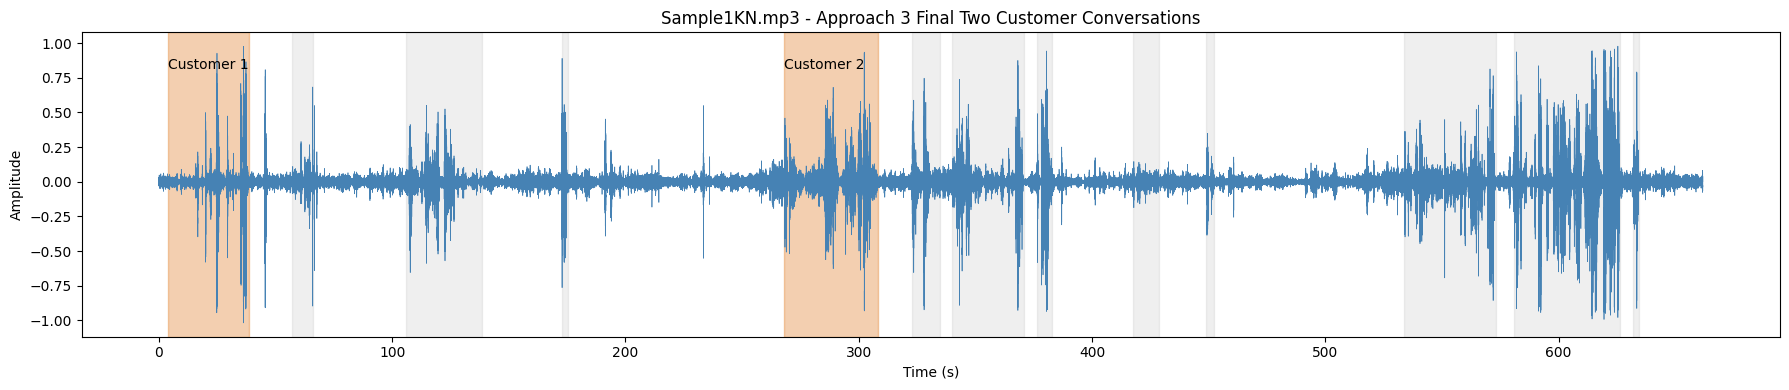

In [16]:
plot_waveform_with_selected_conversations(
    example_result["waveform"],
    example_result["sample_rate"],
    example_result["conversation_candidates"],
    example_result["final_two_conversations"],
    title=f"{example_result['audio_name']} - Approach 3 Final Two Customer Conversations",
)


## Standard Outputs

Each approach now writes the same comparable output structure. For each audio file:

- `*_conversation_candidates.csv`: candidate conversation blocks generated by this approach.
- `*_final_two_conversations.csv`: the final predicted two customer conversation windows.
- `*_tagged_conversation_candidates.csv`: the candidate blocks annotated with whether they contributed to customer 1, customer 2, or were not selected.

At the approach folder level:

- `all_files_final_two_conversations.csv`: final predictions across all audio files.
- `evaluation_against_ground_truth.csv`: per-conversation boundary errors and IoU when `ground_truth.json` is available.
- `evaluation_summary.csv`: per-file mean absolute start error, mean absolute end error, and mean IoU.
